# Computer Lab 3: Modeling Planetary Temperature
This notebook will contain the code and write-ups for parts 1.1, 1.2, 1.3, 2.1, 2.2, and potentially 2.3 of the Planetary Climates computer lab. Parts 1.4 and 2.4 will be written up separately.

## Setup
As always, let's load some helpful packages. For this assignment, we will need `numpy` and `matplotlib.pyplot`, as well as `scipy.integrate` for some later calculations.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as integrate

## Section 1: Radiative-Equilibrium Solutions
We begin with the first section of the assignment, **Radiative-Equilibrium Solutions**.

### Part 1.1
Part 1.1 asks us to use the equations discussed in class to compute Earth's temperature as a function of latitude, knowing that the latitude at which ice begins $y_i=0.95$. In radiative equilibrium, we know that $\frac{\partial T}{\partial t} = 0$. We also ignore oceanic-atmospheric effects at this step. This means that our temperature equation is governed by

$$ 0 = Q(1-\alpha(y))s(y)-(A+BT(y)) $$

which we can arrange to find

$$ T(y) = \frac{Q(1-\alpha(y))s(y)-A}{B} $$

Luckily, we already know a good amount of information about this equation. First, Legendre-polynomial fitting tells us that $s(y)\approx1.241-0.723y^2$. By fitting a first-order Taylor expansion to the Stefan-Boltzmann Law, we know that $A = 202 \frac{\mathrm{W}}{\mathrm{m}^2}$ and $B = 1.90 \frac{\mathrm{W}}{\degree\mathrm{C}\cdot\mathrm{m}^2}$. We also know that $Q$ is equal to a quarter of the solar constant, or $Q = 0.25\times1361 = 340.25 \frac{\mathrm{W}}{\mathrm{m}^2}$. Finally, $\alpha(y)$ is a piecewise constant function equal to $\alpha_-=0.32$ if $y\leq y_i$ and $\alpha_+=0.62$ if $y>y_i$. Thus, our equation becomes

$$ T(y) = \frac{340.25(1-\alpha(y))(1.241-0.723y^2)-202}{1.90} $$

Let's define this function in Python, but for a vector of values $y$ --- this will let us plug in an entire linear space into the function later.


In [2]:
def T(y):
    alpha = np.ones_like(y) * 0.62
    alpha[np.where(y <= 0.95)] = 0.32 
    s = 1.241 - 0.723 * np.power(y, 2)
    numerator = 340.25 * (1 - alpha) * s - 202
    return numerator / 1.90

Now, we are asked to plot this function. In class, we modeled only one hemisphere, so $y\in[0,1]$. We can use `numpy` and `matplotlib` to plot $T(y)$ over this range.

Text(0.5, 1.0, 'Latitudinal radiative-equilibrium temperature of the Earth')

<Figure size 640x480 with 0 Axes>

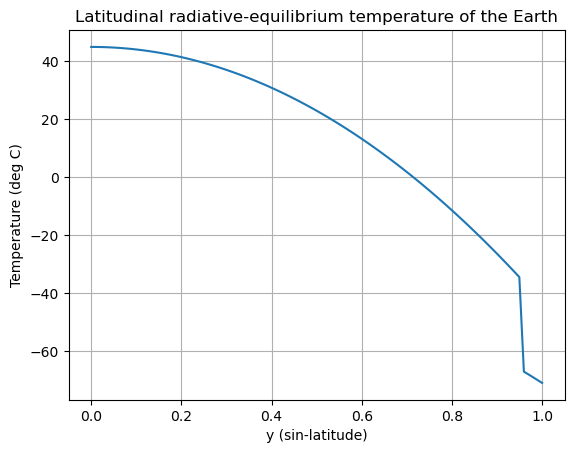

In [3]:
# Calculate function over linspace
y = np.linspace(0, 1, 100)
res = T(y)

# Set up plot
plt.clf()
fig, ax = plt.subplots()

# Plot and label
ax.plot(y, res)
ax.grid()
ax.set_ylabel("Temperature (deg C)")
ax.set_xlabel("y (sin-latitude)")
ax.set_title("Latitudinal radiative-equilibrium temperature of the Earth")

While the shape of the "curve" may seem jarring at first, the jump at $y_i$ makes sense due to the piecewise nature of $\alpha(y)$. In addition, the values seem a bit extreme (over $40\degree\mathrm{C}$ at the equator is likely too hot on average) which makes sense, as we've removed the temperature regulation provided by the coupled oceanic-atmospheric system of the Earth.

### Part 1.2
Now, we are asked to try different values of $y_i$, and to see how the plot of $T(y)$ responds. Let's test with $y_i = 0$, $y_i = 0.25$, $y_i=0.5$, $y_i=0.75$, and $y_i = 1$.

Text(0.5, 1.0, 'Latitudinal radiative-equilibrium temperature of the Earth')

<Figure size 640x480 with 0 Axes>

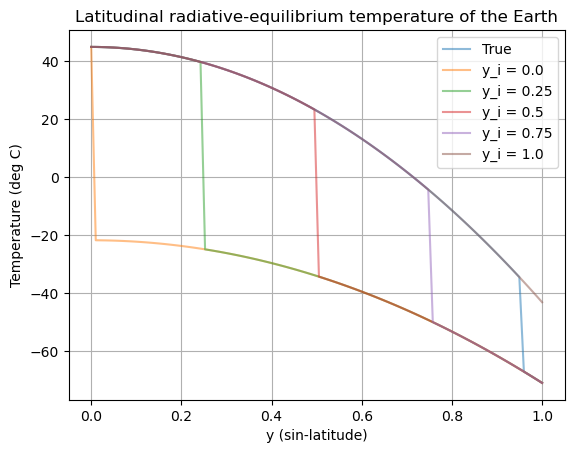

In [4]:
# Define variable-i T(y) function
def T_i(y, i):
    alpha = np.ones_like(y) * 0.62
    alpha[np.where(y <= i)] = 0.32
    s = 1.241 - 0.723 * np.power(y, 2)
    numerator = 340.25 * (1 - alpha) * s - 202
    return numerator / 1.90

# Define linear space
y = np.linspace(0, 1, 100)

# Set up plot
plt.clf()
fig, ax = plt.subplots()

# Plot and label
ax.plot(y, res, label = "True", alpha = 0.5)
for i in range(0, 125, 25):
    ax.plot(y, T_i(y, i / 100), label = "y_i = " + str(i / 100), alpha = 0.5)
ax.set_ylabel("Temperature (deg C)")
ax.set_xlabel("y (sin-latitude)")
ax.legend()
ax.grid()
ax.set_title("Latitudinal radiative-equilibrium temperature of the Earth")

The behavior of $T(y)$ is clear --- even for the edge cases, it holds that the areas below the ice-latitude have significantly higher temperatures (about $60\degree C$ warmer). Don't be fooled by the seeming "jump" for $y_i=0$, either; this is just a visual bug as a result of `numpy`'s inherent use of discrete values. If we plotted the function truly continously, that jump would vanish, and the function's behavior would be consistent. Note that this bug doesn't happen for $y_i=1$ because Python is end-exclusive, so $1$ isn't in the array `y` in the first place.

### Part 1.3
To model the moon as a sphere in radiative equilibrium with an axial tilt of zero degrees, we must first figure out the geometric arrangement of the moon in relation to the Sun's rays. At latitude $\phi$, the orthogonal component of the Sun's rays to the moon's surface will have a magnitude of $S_{\odot}\cos(\phi)$. Since $\cos^2(\phi)+\sin^2(\phi)=1$, we know that $\cos(\phi)=\sqrt{1-y^2}$. Now, we must ensure that

$$\int_0^1s(y)dy=1\rightarrow\int_0^1k\sqrt{1-y^2}dy=1$$

for some constant $k$. We can thus evaluate this integral to find that 

$$\int_0^1\sqrt{1-y^2}dy=\frac{\pi}{4}$$

thus, $k=\frac{4}{\pi}$ and $s(y)=\frac{4}{\pi}\sqrt{1-y^2}$ for the moon. Let's plot this $s(y)$ against Earth's $s(y)$ from earlier.

Text(0.5, 1.0, 'Comparison of s(y) for Earth and the moon')

<Figure size 640x480 with 0 Axes>

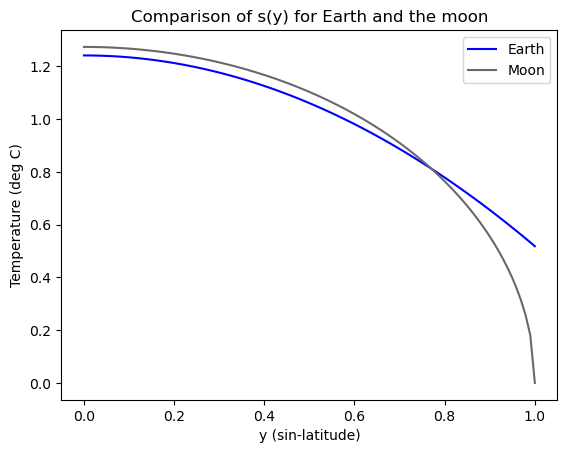

In [5]:
# Calculate s(y) funcs
s_earth = 1.241 - 0.723 * np.power(y, 2)
s_moon = 4/np.pi * np.sqrt(1 - np.power(y, 2))

# Set up plot
plt.clf()
fig, ax = plt.subplots()

# Plot and label
ax.plot(y, s_earth, color = "blue", label = "Earth")
ax.plot(y, s_moon, color = "dimgray", label = "Moon")
ax.legend()
ax.set_xlabel("y (sin-latitude)")
ax.set_ylabel("Temperature (deg C)")
ax.set_title("Comparison of s(y) for Earth and the moon")

We are now asked to calculate both the latitudinal and global-mean temperature of the moon. In class, the temperature of the moon in relation to $y$ is described as

$$ T(y)= \left(\frac{4(1-\alpha)Q}{\delta\sigma}\sqrt{1-y^2}\right)^{\frac{1}{4}} $$

Since the moon is assumed to have a constant $\alpha=0.136$, $\delta=0.9$, and we know $Q=340.25 \frac{\mathrm{W}}{\mathrm{m}^2}$ and $\sigma=5.67\times10^{-8} \frac{\mathrm{W}}{\mathrm{m}^2\cdot\mathrm{K}^{-4}}$, we can express the equation as 

$$ T(y) = \left(\frac{4(1-0.136)340.25}{0.9(5.67\times10^{-8})}\sqrt{1-y^2}\right)^{\frac{1}{4}} $$

Let's plot this with respect to latitude.

Text(0.5, 1.0, 'Latitudinal radiative-equilibrium temperature of the moon')

<Figure size 640x480 with 0 Axes>

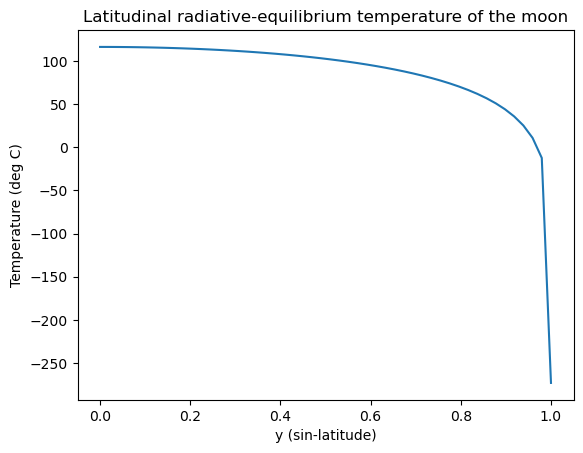

In [6]:
# Define temperature function
def T_moon(y):
    const = (4*(1-0.136)*340.25)/(0.9*5.67*10**(-8))
    unpowered = const * np.sqrt(1 - np.power(y, 2))
    return np.power(unpowered, 1/4) - 273.15 # Keeping temp in Celsius, for now

# Calculate function over linspace
y = np.linspace(0, 1, 50)
res = T_moon(y)

# Set up plot
plt.clf()
fig, ax = plt.subplots()

# Plot and label
ax.plot(y, res)
ax.set_ylabel("Temperature (deg C)")
ax.set_xlabel("y (sin-latitude)")
ax.set_title("Latitudinal radiative-equilibrium temperature of the moon")

Looking back at our comparative plot of $s(y)$, we expect the moon's temperature to drop much more suddenly near the poles, and that's definitely reflected in the plot above. However, unlike Earth's temperature plot, the moon's has no abrupt jumps (it is "smooth") because of the constant albedo rather than the piecewise definition that we used for Earth.

Moving forward, we can also find the average temperature of the moon by integrating our temperature function between $y=0$ and $y=1$. For this, we will use `scipy.integrate`.

In [7]:
T_moon_avg, err = integrate.quad(T_moon, 0, 1)
T_moon_avg

89.53325245760577

Looking at our plot, an average $\overline{T}=89.533\degree\mathrm{C}$ absolutely seems reasonable.

## Section 2: Equilibrium Solutions
We now shift our focus to **Equilibrium Solutions** overall.

### Part 2.1
Our first step to solve part 2.1 is to solve the cubic polynomial we're given for $T(y)$ by plugging in $y_i$ and reducing. Unsimplified, the plugged-in expression says

$$ T(y_i) = \frac{Q}{B+C}\left((1.241-0.723y_i^2)(1-\alpha(y_i)) + \frac{C}{B}(1 - (\alpha_++(\alpha_--\alpha_+)y_i(1.244-0.244y_i^2)))\right) - \frac{A}{B} $$

Knowing that $\alpha_-=0.32$, $\alpha_+=0.62$, and assuming $\alpha(y_i)$ is the average of the two (so $0.47$), we can write

$$ T(y_i) = \frac{Q}{B+C}\left(0.53(1.241-0.723y_i^2) + \frac{C}{B}(0.38 - 0.3y_i(1.244-0.244y_i^2))\right) - \frac{A}{B} $$

Also knowing that $T(y_i)=-10\degree C$ and with our earlier values of $A$, $B$, $C$, and $Q$, we can now say

$$ -10 = 68.88\left(0.53(1.241-0.723y_i^2)+1.6(0.38 - 0.3y_i(1.244-0.244y_i^2))\right) - 106.32 $$

which, with plenty of simplification, becomes 

$$ -7.71y_i^3-26.39y_i^2+40.77y_i-9.14=0 $$

Let's use `numpy` to find the roots of this cubic polynomial.


In [8]:
p = np.array([-7.71, -26.39, 40.77, -9.14])
sols = np.roots(p)
sols

array([-4.62231434,  0.92102939,  0.27845746])

Recall that viable $y_i$ solution must be between $0$ and $1$, meaning our two valid solutions are $y_i=0.278$ and $y_i=0.921$, which, especially considering the rounding we've done, is a relatively good estimate of our current value $y_i=0.95$ (though we will see if we can improve this estimate later on in the assignment). Thus, for this part of the assignment, we will consider $y_i\in\{0, 0.278, 0.921, 1\}$ as our ice-covered, partially ice-covered, and ice free solutions, respectively. Let's redefine our $T(y)$ function with $Q=343\frac{\mathrm{W}}{\mathrm{m}^2}$, and plot each possibility.

Text(0.5, 1.0, 'Latitudinal equilibrium temperature of the Earth')

<Figure size 640x480 with 0 Axes>

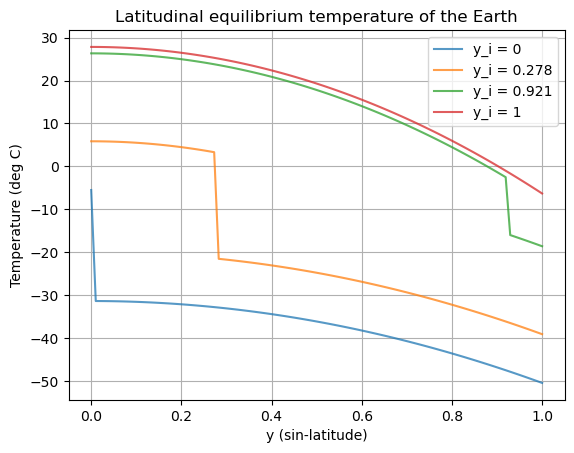

In [9]:
# Define T(y)
def T_i(y, i):
    y = np.atleast_1d(np.array(y))
    alpha = np.ones_like(y) * 0.62
    if np.where(y <= i)[0].size > 0:
        alpha[np.where(y <= i)] = 0.32
    s = 1.241 - 0.723 * np.power(y, 2)
    first = (343 / (1.9 + 3.04))
    second = 3.04 / 1.9
    alpha_bar = 0.62 - 0.3 * i * (1.244 - 0.244 * i ** 2)
    third = 202 / 1.9
    result = first * (s * (1 - alpha) + second * (1 - alpha_bar)) - third
    return result

# Define linear space
y = np.linspace(0, 1, 100)

# Set up plot
plt.clf()
fig, ax = plt.subplots()

# Plot and label
for i in [0, 0.278, 0.921, 1]:
    ax.plot(y, T_i(y, i), label = "y_i = " + str(i), alpha = 0.75)
ax.set_ylabel("Temperature (deg C)")
ax.set_xlabel("y (sin-latitude)")
ax.legend()
ax.grid()
ax.set_title("Latitudinal equilibrium temperature of the Earth")

The results of our system's equilibrium, rather than just its radiative equilibrium, are certainly clear in this plot, with each curve's magnitude now differing based on $y_i$. Let's calculate $\overline{T}$ for each solution, as well.

In [10]:
T_bars = {}
for i in [0, 0.278, 0.921, 1]:
    res, err = integrate.quad(T_i, 0, 1, args = (i,))
    T_bars[i] = res

T_bars

{0: -37.715789473684204,
 0.278: -19.286199484357592,
 0.921: 14.001892238132431,
 1: 16.442105263157885}

These all seem reasonable for Earth's average temperature, at least according to the plot above. The rather dramatic jump between the average temperatures of $y_i=0$ and $y_i=0.278$ compares to $y_i=0.921$ and $y_i=1$ is reflected not only in the graph, but also in our results for $\overline{T}$.

### Part 2.2

Now, we are asked to let $Q$ vary. This will require some work to figure out; instead of solving the polynomial by hand, let's use Python's symbolic algebra capabilities from the `sympy` library to solve the equation in the form 

$$ T(y_i) = \frac{Q}{B+C}\left(s(y)(1-\alpha(y_i)) + \frac{C}{B}(1 - \overline{\alpha})\right) - \frac{A}{B} $$

where $s(y) = (1.241-0.723y_i^2)$ and $\overline{\alpha}=(\alpha_++(\alpha_--\alpha_+)y_i(1.244-0.244y_i^2))$. This will allow us to vary $Q$ and see what results we get for $y_i$.

In [11]:
from sympy import roots, real_roots, all_roots, nroots, evalf
from sympy.abc import q, y

# Define constants
A = 202
B = 1.90
C = 3.04
T_i = -10
alpha_plus = 0.62
alpha_minus = 0.32

# Define s(y)
def s(y):
    return 1.241 - 0.723 * y ** 2

# Define alpha_bar
def alpha_bar(y):
    return alpha_plus + (alpha_minus - alpha_plus) * y * (1.244 - 0.244 * y ** 2)

# Set up equation -- call y_i "y"
Q = 343
sln = real_roots(Q / (B + C) * (s(y) * (1 - (alpha_plus + alpha_minus) / 2) + (C / B) * (1 - alpha_bar(y))) - A / B - T_i, y)
for root in sln:
    print(root.evalf(3))

-4.47
0.245
0.949


Using `sympy`, we can now see our three roots in much more accurate detail --- we have one invalid root in $-4.47$, then two valid roots in $0.245$ and $0.949$. The latter is much closer to our expected true value of $y_i$ than before, so let's continue to use `sympy` for part 2.2. For simplicity, we will say that $Q$ takes every possible integer value between $250$ and $500 \frac{\mathrm{W}}{\mathrm{m}^2}$ and begin with the $\overline{T}$ calculations.

In [12]:
# Find possible y_i for all valid Q
valid_i = {}
for Q in range(250, 501, 1):
    sln = real_roots(Q / (B + C) * (s(y) * (1 - (alpha_plus + alpha_minus) / 2) + (C / B) * (1 - alpha_bar(y))) - A / B - T_i, y)
    valid_roots = []
    for root in sln:
        ev = root.evalf(3)
        if (0 <= ev) & (ev <= 1):
            valid_roots.append(ev)
    valid_i[Q] = valid_roots

# Define T(y) dependent in y_i and Q
def T_i_Q(y, i, Q):
    return Q / (B + C) * (s(y) * (1 - (alpha_plus + alpha_minus) / 2) + (C / B) * (1 - alpha_bar(i))) - A / B - T_i

# Find all valid T_bar
valid_T_bar = {}
y = np.linspace(0, 1, 100)
for Q in valid_i.keys():
    i_list = []
    if(len(valid_i[Q]) > 0):
        for i in valid_i[Q]:
            T_bar, err = integrate.quad(T_i_Q, 0, 1, args = (i, Q))
            i_list.append(T_bar)
        valid_T_bar[Q] = i_list

In [13]:
# Separate first and second solutions
T_bars_i1 = []
T_bars_i2 = []
valid_Q = list(valid_T_bar.keys())
valid_Q_i2 = []
for Q in valid_Q:
    if len(valid_T_bar[Q]) == 1:
        T_bars_i1.append(valid_T_bar[Q][0])
    else:
        T_bars_i1.append(valid_T_bar[Q][0])
        T_bars_i2.append(valid_T_bar[Q][1])
        valid_Q_i2.append(Q)

In [14]:
# Integrate for y_i = 0
T_bars_zero = []
for Q in range(250, 501, 1):
    T_bar, err = integrate.quad(T_i_Q, 0, 1, args = (0, Q))
    T_bars_zero.append(T_bar)

# Integrate for y_i = 1
T_bars_one = []
for Q in range(250, 501, 1):
    T_bar, err = integrate.quad(T_i_Q, 0, 1, args = (1, Q))
    T_bars_one.append(T_bar)

Text(0.5, 0, 'Q (Wm^(-2))')

<Figure size 640x480 with 0 Axes>

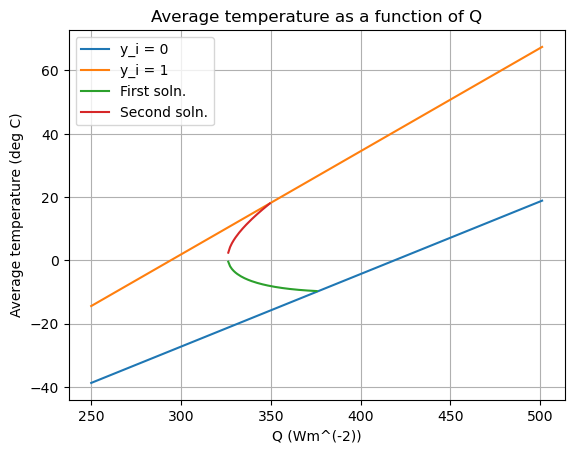

In [15]:
# Pad y_i solutions for plot
T_bars_i1_pad = np.pad(np.array(T_bars_i1), (valid_Q[0] - 250, 500 - valid_Q[-1]), mode = 'constant', constant_values = np.nan)
T_bars_i2_pad = np.pad(np.array(T_bars_i2), (valid_Q_i2[0] - 250, 500 - valid_Q_i2[-1]), mode = 'constant', constant_values = np.nan)

# Set up plot
plt.clf()
fig, ax = plt.subplots()

# Plot solutions
Qs = np.linspace(250, 501, 251)
ax.plot(Qs, T_bars_zero, label = "y_i = 0")
ax.plot(Qs, T_bars_one, label = "y_i = 1")
ax.plot(Qs, T_bars_i1_pad, label = "First soln.")
ax.plot(Qs, T_bars_i2_pad, label = "Second soln.")

# Label plot
ax.grid()
ax.legend()
ax.set_title("Average temperature as a function of Q")
ax.set_ylabel("Average temperature (deg C)")
ax.set_xlabel("Q (Wm^(-2))")

This plot is really interesting, and a further analysis of stability will certainly give us more insight on perhaps why the plot is shaped the way it is. However, it seems that the ice-covered and ice-free solutions are somewhat "connected" by both partially ice-covered solutions.
  
Next, we are asked to plot the location of the ice line, $y_i$, against $Q$. Luckily, we've actually compiled that information already, and just need to isolate it in a way that makes it easy to plot.

In [22]:
# Separate first and second solutions
valid_i1 = []
valid_i2 = []
for Q in valid_Q:
    if len(valid_i[Q]) == 1:
        valid_i1.append(valid_i[Q][0])
    else:
        valid_i1.append(valid_i[Q][0])
        valid_i2.append(valid_i[Q][1])

# Pad y_i solutions for plot
valid_i1_pad = np.pad(np.array(valid_i1), (valid_Q[0] - 250, 500 - valid_Q[-1]), mode = 'constant', constant_values = np.nan)
valid_i2_pad = np.pad(np.array(valid_i2), (valid_Q_i2[0] - 250, 500 - valid_Q_i2[-1]), mode = 'constant', constant_values = np.nan)

Text(0.5, 0, 'Q (Wm^(-2))')

<Figure size 640x480 with 0 Axes>

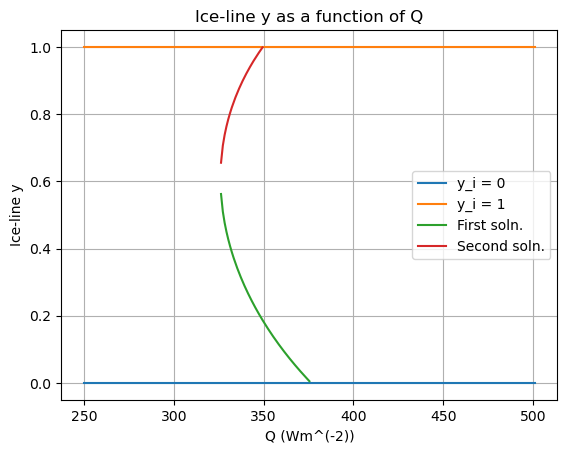

In [27]:
# Set up plot
plt.clf()
fig, ax = plt.subplots()

# Plot solutions
Qs = np.linspace(250, 501, 251)
ax.plot(Qs, np.zeros_like(Qs), label = "y_i = 0")
ax.plot(Qs, np.ones_like(Qs), label = "y_i = 1")
ax.plot(Qs, valid_i1_pad , label = "First soln.")
ax.plot(Qs, valid_i2_pad, label = "Second soln.")

# Label plot
ax.grid()
ax.legend()
ax.set_title("Ice-line y as a function of Q")
ax.set_ylabel("Ice-line y")
ax.set_xlabel("Q (Wm^(-2))")

This plot has similar behavior to the plot of $\overline{T}$, which makes sense due to the fundamental connection between $y_i$ and $T$.

<p style="color:red"> TODO: Explain gap? Summarize 2.2 </p>